In [1]:
import torch
import joblib
import numpy as np
import pandas as pd
import concurrent.futures
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from astropy.timeseries import BoxLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [ ]:
BASELINE_DAYS = 270.0 

def extract_features_from_flux(flux_1d, baseline_days=BASELINE_DAYS):
    """
    Same feature set as before, but operates on the pre-baked 50k-point
    median-centred flux from cnn_dataset.pt. Reconstructs a time axis in
    days by assuming a fixed observation baseline.
    """
    y = flux_1d.astype(float)
    n = len(y)
    cadence = baseline_days / n
    t_days  = np.linspace(0, baseline_days, n)

    # --- Noise estimate ---
    sigma = float(np.nanstd(y))

    pcts = np.nanpercentile(y, [1, 5, 10, 50, 90, 95, 99])

    features = {
        "skew":                      float(skew(y, nan_policy="omit")),
        "kurtosis":                  float(kurtosis(y, nan_policy="omit")),
        "negative_outlier_fraction": float(np.mean(y < -3.0 * sigma)) if sigma > 0 else np.nan,
    }

    # --- Flare features ---
    positive  = np.clip(y, 0.0, None)
    above_3   = y > 3.0 * sigma
    above_5   = y > 5.0 * sigma
    longest_run, current_run = 0, 0
    for flag in above_3:
        current_run = (current_run + 1) if flag else 0
        longest_run = max(longest_run, current_run)

    features.update({
        "flare_p99_snr":                    float(np.nanpercentile(y, 99) / sigma) if sigma > 0 else np.nan,
        "flare_positive_area_ppm_day":      float(np.nansum(positive) * cadence),
        "flare_positive_fraction_3sigma":   float(np.mean(above_3)),
        "flare_longest_run_3sigma":         float(longest_run),
        "flare_longest_duration_3sigma_days": float(longest_run * cadence),
    })

    # --- BLS features (periods in real days via reconstructed time axis) ---
    try:
        periods   = np.geomspace(2.0, 100.0, 160)
        durations = np.array([0.08, 0.16, 0.32, 0.64])
        dy_arr    = np.full_like(y, max(sigma, 1.0))
        result    = BoxLeastSquares(t_days, y, dy=dy_arr).power(
                        periods, durations, objective="snr")
        power     = np.where(np.isfinite(result.power), result.power, np.nan)
        if np.all(np.isnan(power)):
            raise ValueError
        best      = int(np.nanargmax(power))
        depth     = float(np.ravel(result.depth)[best])
        depth_err = float(np.ravel(result.depth_err)[best])
        bls = {
            "bls_power":        float(power[best]),
            "bls_depth_ppm":    depth,
            "bls_depth_snr":    float(abs(depth) / depth_err) if depth_err > 0 else np.nan,
        }
        bls = {k: v if np.isfinite(v) else np.nan for k, v in bls.items()}
    except Exception:
        bls = {k: np.nan for k in
               ["bls_power",
                "bls_depth_ppm", "bls_depth_snr"]}

    features.update(bls)
    return features

In [3]:
def build_feature_table_from_pt(pt_path="cnn_dataset.pt", max_workers=4):
    """
    Loads the pre-baked tensor cache and extracts the hand-crafted feature
    vector from each light curve. The underlying flux is identical to what
    the CNN sees, so train/val splits are directly comparable.
    """
    data    = torch.load(pt_path, map_location="cpu")
    X_all   = data['X'].squeeze(1).numpy()   # (N, 50000)
    y_all   = data['y'].numpy()              # (N, 2): [is_flare, is_transit]
    ids     = data['ids']

    def _worker(i):
        row = extract_features_from_flux(X_all[i])
        row['system_id']   = ids[i]
        # Store the individual indicators explicitly
        row['has_flare']   = int(y_all[i, 0])
        row['has_transit'] = int(y_all[i, 1])
        return row

    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
        rows = list(tqdm(ex.map(_worker, range(len(X_all))),
                         total=len(X_all), desc="Extracting features"))

    return pd.DataFrame(rows)

feature_df = build_feature_table_from_pt("../../data/models/cnn_dataset.pt")
print(feature_df.shape)

# Check the distribution of your two new binary target columns instead!
print("\nFlare distribution:")
print(feature_df["has_flare"].value_counts())

print("\nTransit distribution:")
print(feature_df["has_transit"].value_counts())

Extracting features: 100%|██████████| 1485/1485 [00:23<00:00, 63.14it/s]

(1485, 14)

Flare distribution:
has_flare
1    757
0    728
Name: count, dtype: int64

Transit distribution:
has_transit
0    743
1    742
Name: count, dtype: int64


In [4]:
# Load the exact same indices the CNN used
split       = torch.load("../../data/models/split_indices.pt")
train_idx   = split['train_indices']
val_idx     = split['val_indices']

# Strip out both label columns from features
feature_cols = [c for c in feature_df.columns if c not in {'system_id', 'has_flare', 'has_transit'}]
X_all_feat   = feature_df[feature_cols].values

# Extract a 2D array target: shape (N, 2)
y_all_labels = feature_df[['has_flare', 'has_transit']].values

X_train, X_val = X_all_feat[train_idx], X_all_feat[val_idx]
y_train, y_val = y_all_labels[train_idx], y_all_labels[val_idx]

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")

UnpicklingError: invalid load key, 'v'.

In [ ]:
rf_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_clf.fit(X_train, y_train)

# Evaluate
# Evaluate
y_pred = rf_clf.predict(X_val)  # Shape is now (N_val, 2)

targets = ['has_flare', 'has_transit']
for idx, name in enumerate(targets):
    print(f"\n{"="*10} Metrics for: {name} {"="*10}")
    
    print("Confusion Matrix:")
    print(pd.DataFrame(
        confusion_matrix(y_val[:, idx], y_pred[:, idx], labels=[0, 1]),
        index=["true_no", "true_yes"],
        columns=["pred_no", "pred_yes"]
    ))
    
    print("\nClassification Report:")
    print(classification_report(y_val[:, idx], y_pred[:, idx], target_names=["no", "yes"]))

Confusion Matrix:
              pred_both  pred_flare  pred_neither  pred_transit
true_both            44          25             2             5
true_flare            9          46             3             4
true_neither          0           0            66            19
true_transit          0           0            27            47

Classification Report:
              precision    recall  f1-score   support

        both       0.83      0.58      0.68        76
       flare       0.65      0.74      0.69        62
     neither       0.67      0.78      0.72        85
     transit       0.63      0.64      0.63        74

    accuracy                           0.68       297
   macro avg       0.69      0.68      0.68       297
weighted avg       0.70      0.68      0.68       297

Saved to ../data/models/rf_checkpoint.joblib


In [ ]:
# ── SAVE FEATURE COLS TO TXT ───────────────────────────────────────────────
with open("../../data/models/feature_columns.txt", "w") as f:
    for col in feature_cols:
        f.write(f"{col}\n")
print("Saved feature columns to feature_columns.txt")
# ───────────────────────────────────────────────────────────────────────────

Saved feature columns to feature_columns.txt


In [ ]:
# --- Build full_analysis for the validation set ---
df_meta = pd.read_csv("../../data/input_labels/paired_simulation_labels_combined.csv")

val_system_ids = feature_df.iloc[val_idx]['system_id'].values
y_pred_val     = rf_clf.predict(X_val)
y_proba_val    = rf_clf.predict_proba(X_val)

prob_df = pd.DataFrame(
    y_proba_val,
    columns=[f"p_{c}" for c in rf_classes]
)

results_df = pd.DataFrame({
    'system_id':        val_system_ids,
    'true_event_class': y_val,
    'pred_event_class': y_pred_val,
}).reset_index(drop=True)

results_df = pd.concat([results_df, prob_df.reset_index(drop=True)], axis=1)

# Merge in the physical parameters (transit_radius_earth, flare_amplitude, drift, ...)
full_analysis = pd.merge(results_df, df_meta, on='system_id', how='left')

full_analysis.to_csv("../../data/models/rf_full_analysis.csv", index=False)
print(f"Saved rf_full_analysis.csv  ({len(full_analysis)} rows)")
print(full_analysis.columns.tolist())

Saved rf_full_analysis.csv  (297 rows)
['system_id', 'true_event_class', 'pred_event_class', 'p_both', 'p_flare', 'p_neither', 'p_transit', 'master_seed', 'anomaly_class', 'label_has_flares', 'label_has_transit', 'star_mass', 'star_teff', 'star_logg', 'flare_amplitude', 'transit_period', 'transit_radius_earth', 'drift']


In [ ]:
full_analysis = pd.read_csv("../../data/models/rf_full_analysis.csv")

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


                      prob  count
bin                              
(0.185, 1.427]    0.318182     66
(1.427, 2.645]    0.785714     42
(2.645, 3.863]    1.000000     17
(3.863, 5.08]     1.000000      7
(5.08, 6.298]     1.000000      5
(6.298, 7.516]    1.000000      3
(7.516, 8.734]    1.000000      3
(8.734, 9.951]    1.000000      2
(9.951, 11.169]   1.000000      1
(12.387, 13.604]  1.000000      2
(13.604, 14.822]  1.000000      1
(23.346, 24.564]  1.000000      1


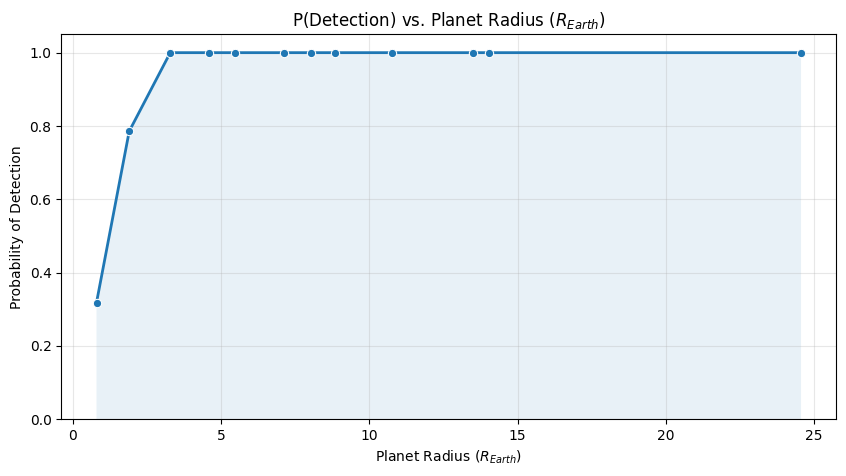

In [ ]:
def plot_detection_probability(df_analysis, feature_col, label, bins=10):
    # Filter only for systems that actually HAVE a transit
    transit_systems = df_analysis[df_analysis['true_event_class'].isin(['transit', 'both'])].copy()
    
    # A "detection" is when the model correctly identifies a transit component
    transit_systems['is_detected'] = transit_systems['pred_event_class'].isin(['transit', 'both']).astype(int)
    
    # Create bins
    transit_systems['bin'] = pd.cut(transit_systems[feature_col], bins=bins)
    
    # Calculate P(detection) per bin
    bin_stats = transit_systems.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1)

    print(bin_stats[['prob', 'count']])
    
    plt.title(f"P(Detection) vs. {label}")
    plt.xlabel(label)
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# Run for Planet Radius
plot_detection_probability(full_analysis, 'transit_radius_earth', "Planet Radius ($R_{Earth}$)", bins=20)

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Stats for No Drift only:
                     prob  count
bin                             
(0.185, 1.427]    0.22500     40
(1.427, 2.645]    0.78125     32
(2.645, 3.863]    1.00000     13
(3.863, 5.08]     1.00000      6
(5.08, 6.298]     1.00000      5
(6.298, 7.516]    1.00000      2
(7.516, 8.734]    1.00000      1
(8.734, 9.951]    1.00000      1
(9.951, 11.169]   1.00000      1
(12.387, 13.604]  1.00000      2
(23.346, 24.564]  1.00000      1


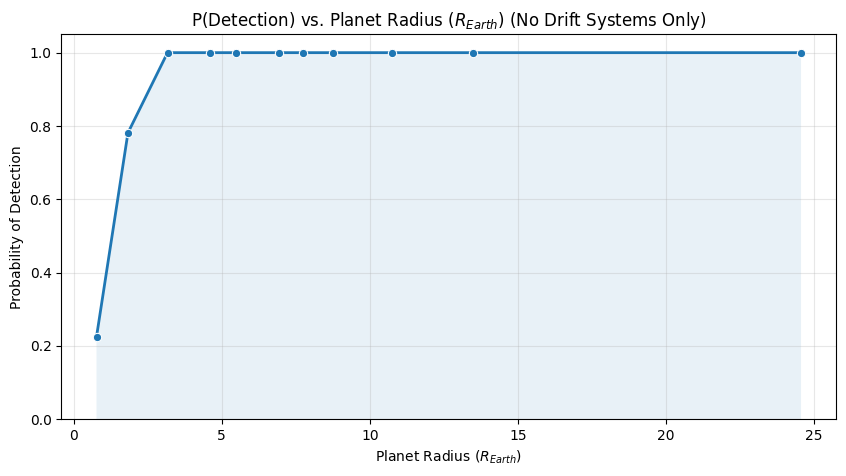

In [ ]:
def plot_detection_probability_low_drift(df_analysis, feature_col, label, bins=40, drift_col='drift'):
    # 1. Filter for LOW DRIFT systems first
    # Adjust 'low' if your data uses a different label (e.g., 'none', 'low')
    df_low = df_analysis[df_analysis[drift_col] == 'none'].copy()
    
    # 2. Filter for systems that actually have a transit
    transit_systems = df_low[df_low['true_event_class'].isin(['transit', 'both'])].copy()
    
    # A "detection" is when the model correctly identifies a transit component
    transit_systems['is_detected'] = transit_systems['pred_event_class'].isin(['transit', 'both']).astype(int)
    
    # Create bins
    transit_systems['bin'] = pd.cut(transit_systems[feature_col], bins=bins)
    
    # Calculate P(detection) per bin
    bin_stats = transit_systems.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1)

    print(f"Stats for No Drift only:")
    print(bin_stats[['prob', 'count']])
    
    plt.title(f"P(Detection) vs. {label} (No Drift Systems Only)")
    plt.xlabel(label)
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# Run it
plot_detection_probability_low_drift(full_analysis, 'transit_radius_earth', "Planet Radius ($R_{Earth}$)", bins=20)

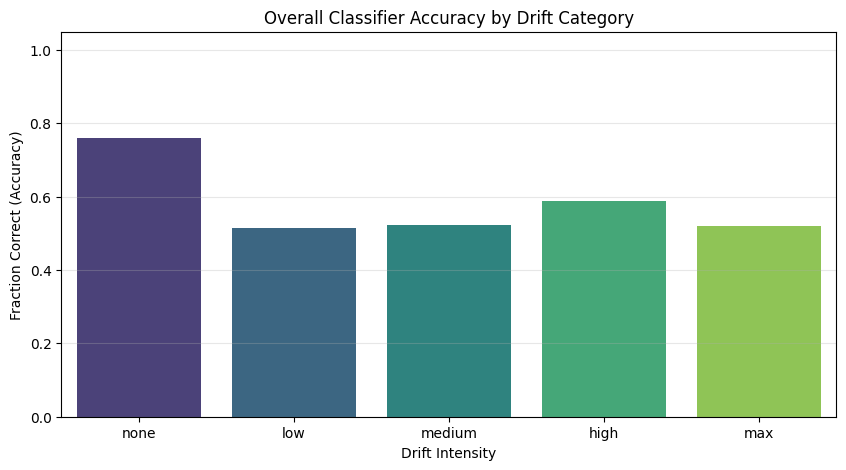

In [ ]:
def plot_accuracy_vs_drift_categorical(df_analysis, drift_col='drift'):
    # 1. Define order
    drift_order = ['none', 'low', 'medium', 'high', 'max']
    
    # 2. Calculate accuracy: Did the model guess the class correctly?
    df_analysis['is_correct'] = (df_analysis['pred_event_class'] == df_analysis['true_event_class']).astype(int)
    
    # 3. Group by category and calculate the mean (fraction correct)
    # We use reindex to enforce your specific order
    stats = df_analysis.groupby(drift_col, observed=True)['is_correct'].mean().reindex(drift_order)
    
    # 4. Plot
    plt.figure(figsize=(10, 5))
    # Using 'hue' is required by modern Seaborn to avoid the FutureWarning
    sns.barplot(x=stats.index, y=stats.values, hue=stats.index, palette='viridis', legend=False)
    
    plt.title("Overall Classifier Accuracy by Drift Category")
    plt.ylabel("Fraction Correct (Accuracy)")
    plt.xlabel("Drift Intensity")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run it
plot_accuracy_vs_drift_categorical(full_analysis, drift_col='drift')

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Flare Detection Statistics by Bin:
                        efficiency  count
amp_bin                                  
(531.88, 734.337]         0.500000     10
(734.337, 1013.858]       0.941176     17
(1013.858, 1399.778]      1.000000     14
(1399.778, 1932.595]      0.900000     10
(1932.595, 2668.227]      0.944444     18
(2668.227, 3683.872]      0.888889      9
(3683.872, 5086.117]      1.000000     12
(5086.117, 7022.118]      0.777778      9
(7022.118, 9695.047]      1.000000     12
(9695.047, 13385.412]     1.000000     10
(13385.412, 18480.492]    0.866667     15


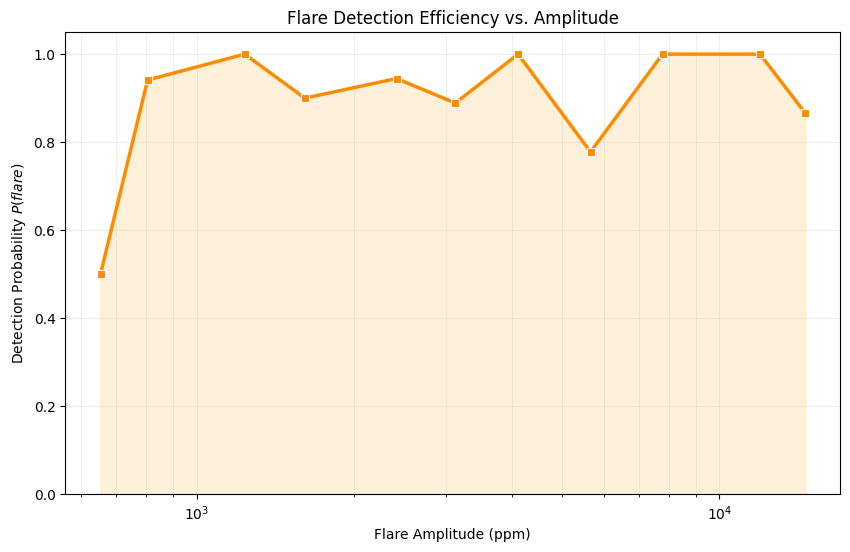

In [ ]:
def plot_flare_detection_efficiency(df_analysis, bins=12):
    # 1. Filter for systems that actually HAVE a flare (Flare or Both)
    flare_systems = df_analysis[df_analysis['true_event_class'].isin(['flare', 'both'])].copy()
    
    # 2. A detection is when the model correctly identifies a flare component
    # We ignore the transit part for this specific analysis.
    flare_systems['flare_detected'] = flare_systems['pred_event_class'].isin(['flare', 'both']).astype(int)
    
    # 3. Create log-spaced bins for amplitude to handle the wide dynamic range
    # Ensure amplitude is > 0 for log spacing
    min_amp = flare_systems['flare_amplitude'].replace(0, np.nan).min()
    max_amp = flare_systems['flare_amplitude'].max()
    
    log_bins = np.logspace(np.log10(min_amp), np.log10(max_amp), bins)
    flare_systems['amp_bin'] = pd.cut(flare_systems['flare_amplitude'], bins=log_bins)
    
    # 4. Calculate P(detection) per bin
    stats = flare_systems.groupby('amp_bin', observed=True).agg(
        efficiency=('flare_detected', 'mean'),
        midpoint=('flare_amplitude', 'median'),
        count=('flare_detected', 'count')
    )

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stats, x='midpoint', y='efficiency', marker='s', color='darkorange', linewidth=2.5)
    plt.fill_between(stats['midpoint'], 0, stats['efficiency'], color='orange', alpha=0.15)
    
    plt.xscale('log')
    plt.title("Flare Detection Efficiency vs. Amplitude")
    plt.xlabel("Flare Amplitude (ppm)")
    plt.ylabel("Detection Probability $P(flare)$")
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    print("Flare Detection Statistics by Bin:")
    print(stats[['efficiency', 'count']])
    
    plt.show()

# Run the analysis on your test set results
plot_flare_detection_efficiency(full_analysis)

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Flare Detection Statistics (No Drift) by Bin:
                        efficiency  count
amp_bin                                  
(612.944, 834.486]        0.909091     11
(834.486, 1136.102]       1.000000      7
(1136.102, 1546.734]      1.000000      9
(1546.734, 2105.785]      1.000000      8
(2105.785, 2866.899]      1.000000      9
(2866.899, 3903.11]       1.000000      7
(3903.11, 5313.848]       1.000000      8
(5313.848, 7234.483]      1.000000      4
(7234.483, 9849.311]      1.000000      8
(9849.311, 13409.242]     1.000000      8
(13409.242, 18255.871]    1.000000     13


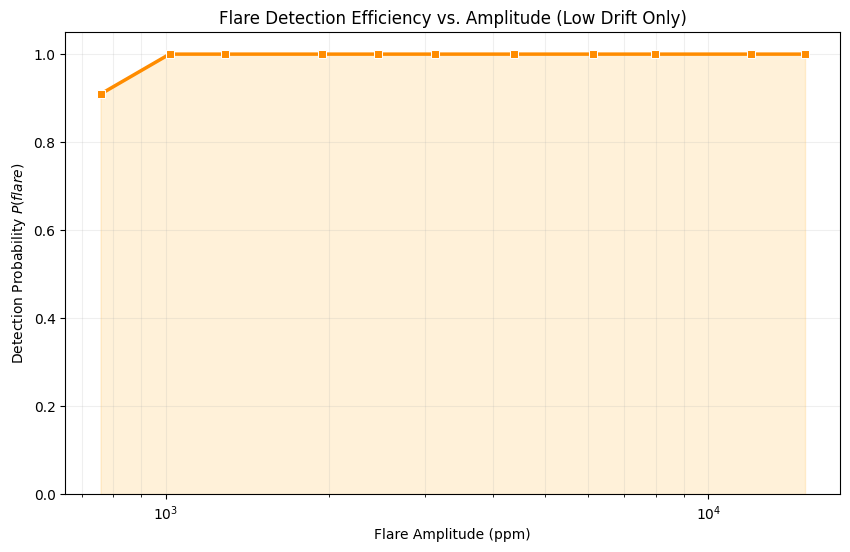

In [ ]:
def plot_flare_detection_efficiency_low_drift(df_analysis, bins=12, drift_col='drift'):
    # 1. Filter for LOW DRIFT systems first
    df_low = df_analysis[df_analysis[drift_col] == 'none'].copy()
    
    # 2. Filter for systems that actually HAVE a flare (Flare or Both)
    flare_systems = df_low[df_low['true_event_class'].isin(['flare', 'both'])].copy()
    
    # 3. A detection is when the model correctly identifies a flare component
    flare_systems['flare_detected'] = flare_systems['pred_event_class'].isin(['flare', 'both']).astype(int)
    
    # 4. Create log-spaced bins for amplitude
    min_amp = flare_systems['flare_amplitude'].replace(0, np.nan).min()
    max_amp = flare_systems['flare_amplitude'].max()
    
    log_bins = np.logspace(np.log10(min_amp), np.log10(max_amp), bins)
    flare_systems['amp_bin'] = pd.cut(flare_systems['flare_amplitude'], bins=log_bins)
    
    # 5. Calculate P(detection) per bin
    stats = flare_systems.groupby('amp_bin', observed=True).agg(
        efficiency=('flare_detected', 'mean'),
        midpoint=('flare_amplitude', 'median'),
        count=('flare_detected', 'count')
    )

    # 6. Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stats, x='midpoint', y='efficiency', marker='s', color='darkorange', linewidth=2.5)
    plt.fill_between(stats['midpoint'], 0, stats['efficiency'], color='orange', alpha=0.15)
    
    plt.xscale('log')
    plt.title("Flare Detection Efficiency vs. Amplitude (Low Drift Only)")
    plt.xlabel("Flare Amplitude (ppm)")
    plt.ylabel("Detection Probability $P(flare)$")
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    print("Flare Detection Statistics (No Drift) by Bin:")
    print(stats[['efficiency', 'count']])
    
    plt.show()

# Run for low drift only
plot_flare_detection_efficiency_low_drift(full_analysis, drift_col='drift')

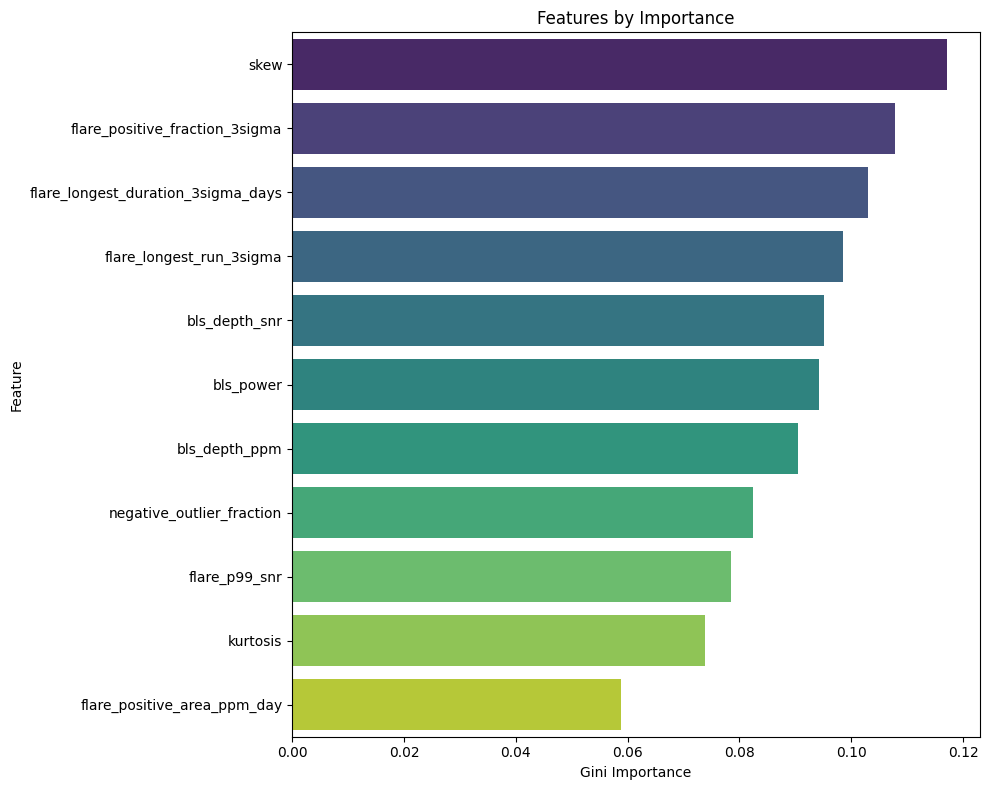

In [ ]:
def plot_feature_importance(clf, feature_names):
    # Extract the random forest from the pipeline
    rf_model = clf.named_steps['model']
    importances = rf_model.feature_importances_
    
    # Create a dataframe for plotting
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
    plt.title(f"Features by Importance")
    plt.xlabel("Gini Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Run it
plot_feature_importance(rf_clf, feature_cols)